# 03-3. RandomForest モデル設計 — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 02で確定した特徴量セット（48特徴量）を使い、RandomForestモデルを構築し、勾配ブースティング系（LightGBM / XGBoost）と比較する。

### 本ノートブックの構成
1. データ読み込み（中間データから）
2. モデル概要と選定理由
3. ハイパーパラメータ設定
4. 時系列バリデーションによる学習
5. 予測結果の分析
6. 特徴量重要度の分析
7. 既存モデルとの比較
8. ハイパーパラメータチューニング（Optuna）
9. まとめと次ステップ

---
## 1. データ読み込み（中間データから）

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
np.random.seed(SEED)
INTERMEDIATE_DIR = Path('./intermediate')
INPUT_DIR = Path('../../input')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 1, None)  # 来客数は1人以上
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 02の中間データ読み込み
with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'rb') as f:
    prev_02 = pickle.load(f)

# 確定済み設定の読み込み
confirmed = prev_02['confirmed_settings']
TRAIN_START = confirmed['best_train_start']
NAN_STRATEGY = confirmed['best_nan_strategy']
ROLLING_CONFIG = confirmed['best_rolling_config']
TRAIN_PERIOD = confirmed['best_train_period']

# バリデーションfold情報の読み込み
val_folds = prev_02['val_folds']

train_df = prev_02['train_features']
valid_df = prev_02['valid_features']
all_features = prev_02['feature_columns']['all_features']
VALID_START = prev_02['VALID_START']

# TRAIN_STARTフィルタの適用
if TRAIN_START is not None:
    train_df = train_df[train_df['visit_date'] >= TRAIN_START].reset_index(drop=True)

# 先行モデルの結果読み込み
with open(INTERMEDIATE_DIR / '03-1_lgbm_results.pkl', 'rb') as f:
    prev_lgbm = pickle.load(f)
with open(INTERMEDIATE_DIR / '03-2_xgb_results.pkl', 'rb') as f:
    prev_xgb = pickle.load(f)

# === 予約特徴量の構築（03-1と同じ処理） ===
hpg_res = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
air_res = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_store_info = pd.read_csv(INPUT_DIR / 'hpg_store_info.csv')
air_store_info = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
store_rel = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')

hpg_res['visit_date'] = hpg_res['visit_datetime'].dt.normalize()
air_res['visit_date'] = air_res['visit_datetime'].dt.normalize()

# city/prefecture をまず小さい hpg_store_info 側で計算してからマージ（メモリ効率改善）
hpg_store_info['city'] = hpg_store_info['hpg_area_name'].str.split(' ').str[:2].str.join(' ')
hpg_store_info['prefecture'] = hpg_store_info['hpg_area_name'].str.split(' ').str[0]
hpg_res = hpg_res.merge(hpg_store_info[['hpg_store_id', 'city', 'prefecture']], on='hpg_store_id', how='left')

air_store_info['city'] = air_store_info['air_area_name'].str.split(' ').str[:2].str.join(' ')
air_store_info['prefecture'] = air_store_info['air_area_name'].str.split(' ').str[0]

hpg_city_daily = hpg_res.groupby(['city', 'visit_date']).agg(
    hpg_city_reserve_visitors=('reserve_visitors', 'sum'),
    hpg_city_reserve_count=('reserve_visitors', 'count')).reset_index()
hpg_pref_daily = hpg_res.groupby(['prefecture', 'visit_date']).agg(
    hpg_pref_reserve_visitors=('reserve_visitors', 'sum')).reset_index()
hpg_direct = hpg_res.merge(store_rel, on='hpg_store_id', how='inner')
hpg_store_daily = hpg_direct.groupby(['air_store_id', 'visit_date']).agg(
    hpg_store_reserve_visitors=('reserve_visitors', 'sum')).reset_index()
air_store_daily = air_res.groupby(['air_store_id', 'visit_date']).agg(
    air_reserve_visitors=('reserve_visitors', 'sum'),
    air_reserve_count=('reserve_visitors', 'count')).reset_index()

def add_reserve_features(df):
    df = df.copy()
    store_city = air_store_info.set_index('air_store_id')[['city', 'prefecture']]
    df = df.merge(store_city, left_on='air_store_id', right_index=True, how='left', suffixes=('', '_res'))
    df = df.merge(hpg_city_daily, on=['city', 'visit_date'], how='left')
    df = df.merge(hpg_pref_daily, on=['prefecture', 'visit_date'], how='left')
    df = df.merge(hpg_store_daily, on=['air_store_id', 'visit_date'], how='left')
    df = df.merge(air_store_daily, on=['air_store_id', 'visit_date'], how='left')
    df['total_reserve_visitors'] = df[['hpg_store_reserve_visitors', 'air_reserve_visitors']].sum(axis=1, min_count=1)
    reserve_cols = ['hpg_city_reserve_visitors', 'hpg_city_reserve_count',
                    'hpg_pref_reserve_visitors', 'hpg_store_reserve_visitors',
                    'air_reserve_visitors', 'air_reserve_count', 'total_reserve_visitors']
    for col in reserve_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df.drop(columns=['city', 'prefecture'], errors='ignore', inplace=True)
    for c in [x for x in df.columns if x.endswith('_res')]:
        df.drop(columns=[c], errors='ignore', inplace=True)
    return df

train_df = add_reserve_features(train_df)
valid_df = add_reserve_features(valid_df)

reserve_features = ['hpg_city_reserve_visitors', 'hpg_city_reserve_count',
                    'hpg_pref_reserve_visitors', 'hpg_store_reserve_visitors',
                    'air_reserve_visitors', 'air_reserve_count', 'total_reserve_visitors']
all_features_v2 = all_features + reserve_features

print('=== 確定済み設定 ===')
for k, v in confirmed.items():
    print(f'  {k}: {v}')
print(f'\n※ RandomForestはNaN非対応のため、best_nan_strategyの値（{NAN_STRATEGY}）に関わらず常にfillna(-999)を使用')

print(f'\n=== バリデーションfold情報 ===')
print(f'  fold数: {len(val_folds)}')
for i, fold in enumerate(val_folds):
    print(f'  Fold {i+1}: 期間={fold["val_start"]}~{fold["val_end"]}')

print(f'\n中間データ読み込み完了')
print(f'  学習データ: {train_df.shape}')
print(f'  検証データ: {valid_df.shape}')
print(f'  特徴量数: {len(all_features)} → {len(all_features_v2)}（予約7追加）')
print(f'\n参考スコア:')
print(f'  LightGBM RMSLE: {prev_lgbm["score_single"]:.5f}')
print(f'  XGBoost  RMSLE: {prev_xgb["score_single"]:.5f}')

---
## 2. モデル概要と選定理由

### RandomForestの特徴

| 項目 | RandomForest | 勾配ブースティング (LGB/XGB) |
|------|-------------|---------------------------|
| 学習方式 | Bagging（独立した木の並列学習） | Boosting（逐次的に残差を学習） |
| 過学習リスク | 低い（個々の木が独立） | やや高い（深い木を連鎖） |
| 精度 | 一般的にやや劣る | 一般的に高い |
| アンサンブル効果 | Boostingと組み合わせると多様性が高い | 同系統同士の組み合わせは効果限定的 |

### 選定理由
- 勾配ブースティングとは**根本的に異なる学習方式**（Bagging vs Boosting）
- アンサンブル時に**多様性を持たせる**ために有効
- 過学習しにくく、ロバストなベースラインとして機能

---
## 3. ハイパーパラメータ設定

| パラメータ | 値 | 根拠 |
|-----------|-----|------|
| `n_estimators` | 500 | 十分な木の数（RFはearly_stopping不要） |
| `max_depth` | 20 | 深めに設定（RFは過学習しにくいため） |
| `min_samples_split` | 10 | 分割に必要な最小サンプル数 |
| `min_samples_leaf` | 5 | リーフの最小サンプル数 |
| `max_features` | 0.8 | 各木で使う特徴量の割合 |
| `max_samples` | 0.8 | 各木で使うサンプルの割合 |

In [2]:
rf_params = {
    'n_estimators': 500,
    'max_depth': 20,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'max_features': 0.8,
    'max_samples': 0.8,
    'random_state': SEED,
    'n_jobs': -1,
}

print('=== RandomForest ハイパーパラメータ ===')
for k, v in rf_params.items():
    print(f'  {k}: {v}')

=== RandomForest ハイパーパラメータ ===
  n_estimators: 500
  max_depth: 20
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: 0.8
  max_samples: 0.8
  random_state: 42
  n_jobs: -1


---
## 4. 時系列バリデーションによる学習

**注意**: RandomForestはNaNを直接扱えないため、欠損値を埋める必要がある。

In [3]:
# === Single Split での学習（予約特徴量追加版 v2: 60特徴量） ===
# RandomForestはNaN非対応のため、-999で埋める（木モデルなのでスケールは無関係）
X_train = train_df[all_features_v2].fillna(-999)
y_train = np.log1p(train_df['visitors'])
X_valid = valid_df[all_features_v2].fillna(-999)
y_valid = np.log1p(valid_df['visitors'])

print(f'欠損値の埋め込み: NaN → -999')
print(f'  学習データの元NaN数: {train_df[all_features_v2].isna().sum().sum():,}')
print(f'  検証データの元NaN数: {valid_df[all_features_v2].isna().sum().sum():,}')

model = RandomForestRegressor(**rf_params)
model.fit(X_train, y_train)

pred_log = model.predict(X_valid)
pred = np.expm1(pred_log)
score_single = rmsle(valid_df['visitors'], pred)

# 学習データのスコアも確認（過学習チェック）
train_pred = np.expm1(model.predict(X_train))
score_train = rmsle(train_df['visitors'], train_pred)

print(f'\n=== Single Split 結果（{len(all_features_v2)}特徴量） ===')
print(f'  学習 RMSLE: {score_train:.5f}')
print(f'  検証 RMSLE: {score_single:.5f}')
print(f'  過学習度合い: {score_train / score_single:.3f} (1.0に近いほど良い)')
print(f'\n  LightGBM RMSLE: {prev_lgbm["score_single"]:.5f}')
print(f'  XGBoost  RMSLE: {prev_xgb["score_single"]:.5f}')
print(f'  RandomForest RMSLE: {score_single:.5f}')

欠損値の埋め込み: NaN → -999
  学習データの元NaN数: 260,867
  検証データの元NaN数: 20,084

=== Single Split 結果（60特徴量） ===
  学習 RMSLE: 0.36926
  検証 RMSLE: 0.51215
  過学習度合い: 0.721 (1.0に近いほど良い)

  LightGBM RMSLE: 0.50253
  XGBoost  RMSLE: 0.48972
  RandomForest RMSLE: 0.51215


In [5]:
# === val_folds ベース Cross-Validation (5-fold, 60特徴量) ===
full_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values('visit_date').reset_index(drop=True)

cv_scores = []

for fold_i, fold in enumerate(val_folds, 1):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])

    train_mask = full_df['visit_date'] < val_start
    valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)

    fold_train = full_df[train_mask]
    fold_valid = full_df[valid_mask]

    if len(fold_train) == 0 or len(fold_valid) == 0:
        print(f'Fold {fold_i}: スキップ（データ不足）')
        continue

    X_tr = fold_train[all_features_v2].fillna(-999)
    y_tr = np.log1p(fold_train['visitors'])
    X_va = fold_valid[all_features_v2].fillna(-999)
    y_va_raw = fold_valid['visitors']

    m = RandomForestRegressor(**rf_params)
    m.fit(X_tr, y_tr)

    p = np.expm1(m.predict(X_va))
    s = rmsle(y_va_raw, p)
    cv_scores.append(s)

    print(f'Fold {fold_i}: RMSLE={s:.5f}  '
          f'(train: {fold_train["visit_date"].min().date()}~{fold_train["visit_date"].max().date()}, '
          f'valid: {fold["val_start"]}~{fold["val_end"]}, '
          f'n_train={len(fold_train):,}, n_valid={len(fold_valid):,})')

print(f'\n=== CV結果（{len(val_folds)}-fold, {len(all_features_v2)}特徴量） ===')
print(f'  RandomForest 平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  LightGBM     平均 RMSLE: {prev_lgbm["cv_mean"]:.5f} (+/- {prev_lgbm["cv_std"]:.5f})')
print(f'  XGBoost      平均 RMSLE: {prev_xgb["cv_mean"]:.5f} (+/- {prev_xgb["cv_std"]:.5f})')

Fold 1: RMSLE=0.51596  (train: 2016-01-01~2016-04-22, valid: 2016-04-23~2016-05-31, n_train=29,116, n_valid=10,336)
Fold 2: RMSLE=0.51136  (train: 2016-01-01~2016-07-15, valid: 2016-07-16~2016-08-23, n_train=58,174, n_valid=26,084)
Fold 3: RMSLE=0.48886  (train: 2016-01-01~2016-10-14, valid: 2016-10-15~2016-11-22, n_train=120,279, n_valid=27,168)
Fold 4: RMSLE=0.52802  (train: 2016-01-01~2016-12-15, valid: 2016-12-16~2017-01-23, n_train=163,715, n_valid=24,817)
Fold 5: RMSLE=0.50867  (train: 2016-01-01~2017-03-14, valid: 2017-03-15~2017-04-22, n_train=224,077, n_valid=28,031)

=== CV結果（5-fold, 60特徴量） ===
  RandomForest 平均 RMSLE: 0.51057 (+/- 0.01272)
  LightGBM     平均 RMSLE: 0.50088 (+/- 0.01300)
  XGBoost      平均 RMSLE: 0.50196 (+/- 0.01378)


In [6]:
# === ルールベースベースライン: 店舗×曜日の中央値 ===
# モデルの付加価値を確認するため、単純な統計量ベースラインと比較する

full_baseline_df = pd.concat([train_df, valid_df], ignore_index=True)
full_baseline_df['dow'] = pd.to_datetime(full_baseline_df['visit_date']).dt.dayofweek

# 学習データから店舗×曜日の中央値を計算
train_baseline = full_baseline_df[full_baseline_df['visit_date'] < VALID_START]
store_dow_median = train_baseline.groupby(['air_store_id', 'dow'])['visitors'].median()

# 検証データに適用
valid_baseline_df = full_baseline_df[full_baseline_df['visit_date'] >= VALID_START].copy()
valid_baseline_df['baseline_pred'] = valid_baseline_df.apply(
    lambda r: store_dow_median.get((r['air_store_id'], r['dow']),
              train_baseline['visitors'].median()), axis=1)

baseline_rmsle = rmsle(valid_baseline_df['visitors'], valid_baseline_df['baseline_pred'])
baseline_pred = valid_baseline_df['baseline_pred'].values

print('=== ルールベースベースライン（店舗×曜日 中央値） ===')
print(f'  ベースライン RMSLE: {baseline_rmsle:.5f}')
print(f'  RandomForest RMSLE: {score_single:.5f}')
print(f'  RF改善幅: {baseline_rmsle - score_single:.5f} ({(baseline_rmsle - score_single)/baseline_rmsle*100:.1f}%)')
print(f'\n  LightGBM     RMSLE: {prev_lgbm["score_single"]:.5f}')
print(f'  XGBoost      RMSLE: {prev_xgb["score_single"]:.5f}')

=== ルールベースベースライン（店舗×曜日 中央値） ===
  ベースライン RMSLE: 0.54977
  RandomForest RMSLE: 0.51215
  RF改善幅: 0.03762 (6.8%)

  LightGBM     RMSLE: 0.50253
  XGBoost      RMSLE: 0.48972


---
## 5. 予測結果の分析

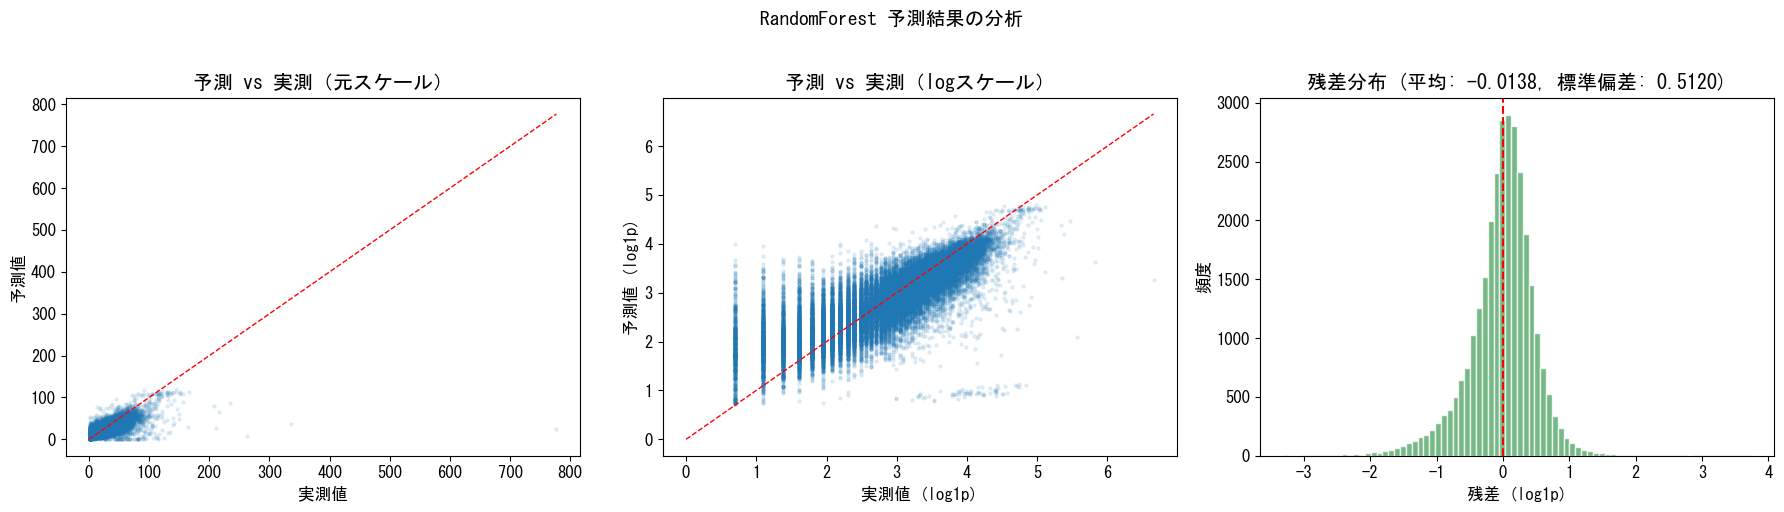

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(valid_df['visitors'], pred, alpha=0.1, s=5)
max_val = max(valid_df['visitors'].max(), pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('実測値')
axes[0].set_ylabel('予測値')
axes[0].set_title('予測 vs 実測（元スケール）')

axes[1].scatter(np.log1p(valid_df['visitors']), pred_log, alpha=0.1, s=5)
max_log = max(np.log1p(valid_df['visitors']).max(), pred_log.max())
axes[1].plot([0, max_log], [0, max_log], 'r--', linewidth=1)
axes[1].set_xlabel('実測値 (log1p)')
axes[1].set_ylabel('予測値 (log1p)')
axes[1].set_title('予測 vs 実測（logスケール）')

residuals = np.log1p(valid_df['visitors'].values) - pred_log
axes[2].hist(residuals, bins=80, color='#55A868', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('残差 (log1p)')
axes[2].set_ylabel('頻度')
axes[2].set_title(f'残差分布 (平均: {residuals.mean():.4f}, 標準偏差: {residuals.std():.4f})')

plt.suptitle('RandomForest 予測結果の分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. 特徴量重要度の分析

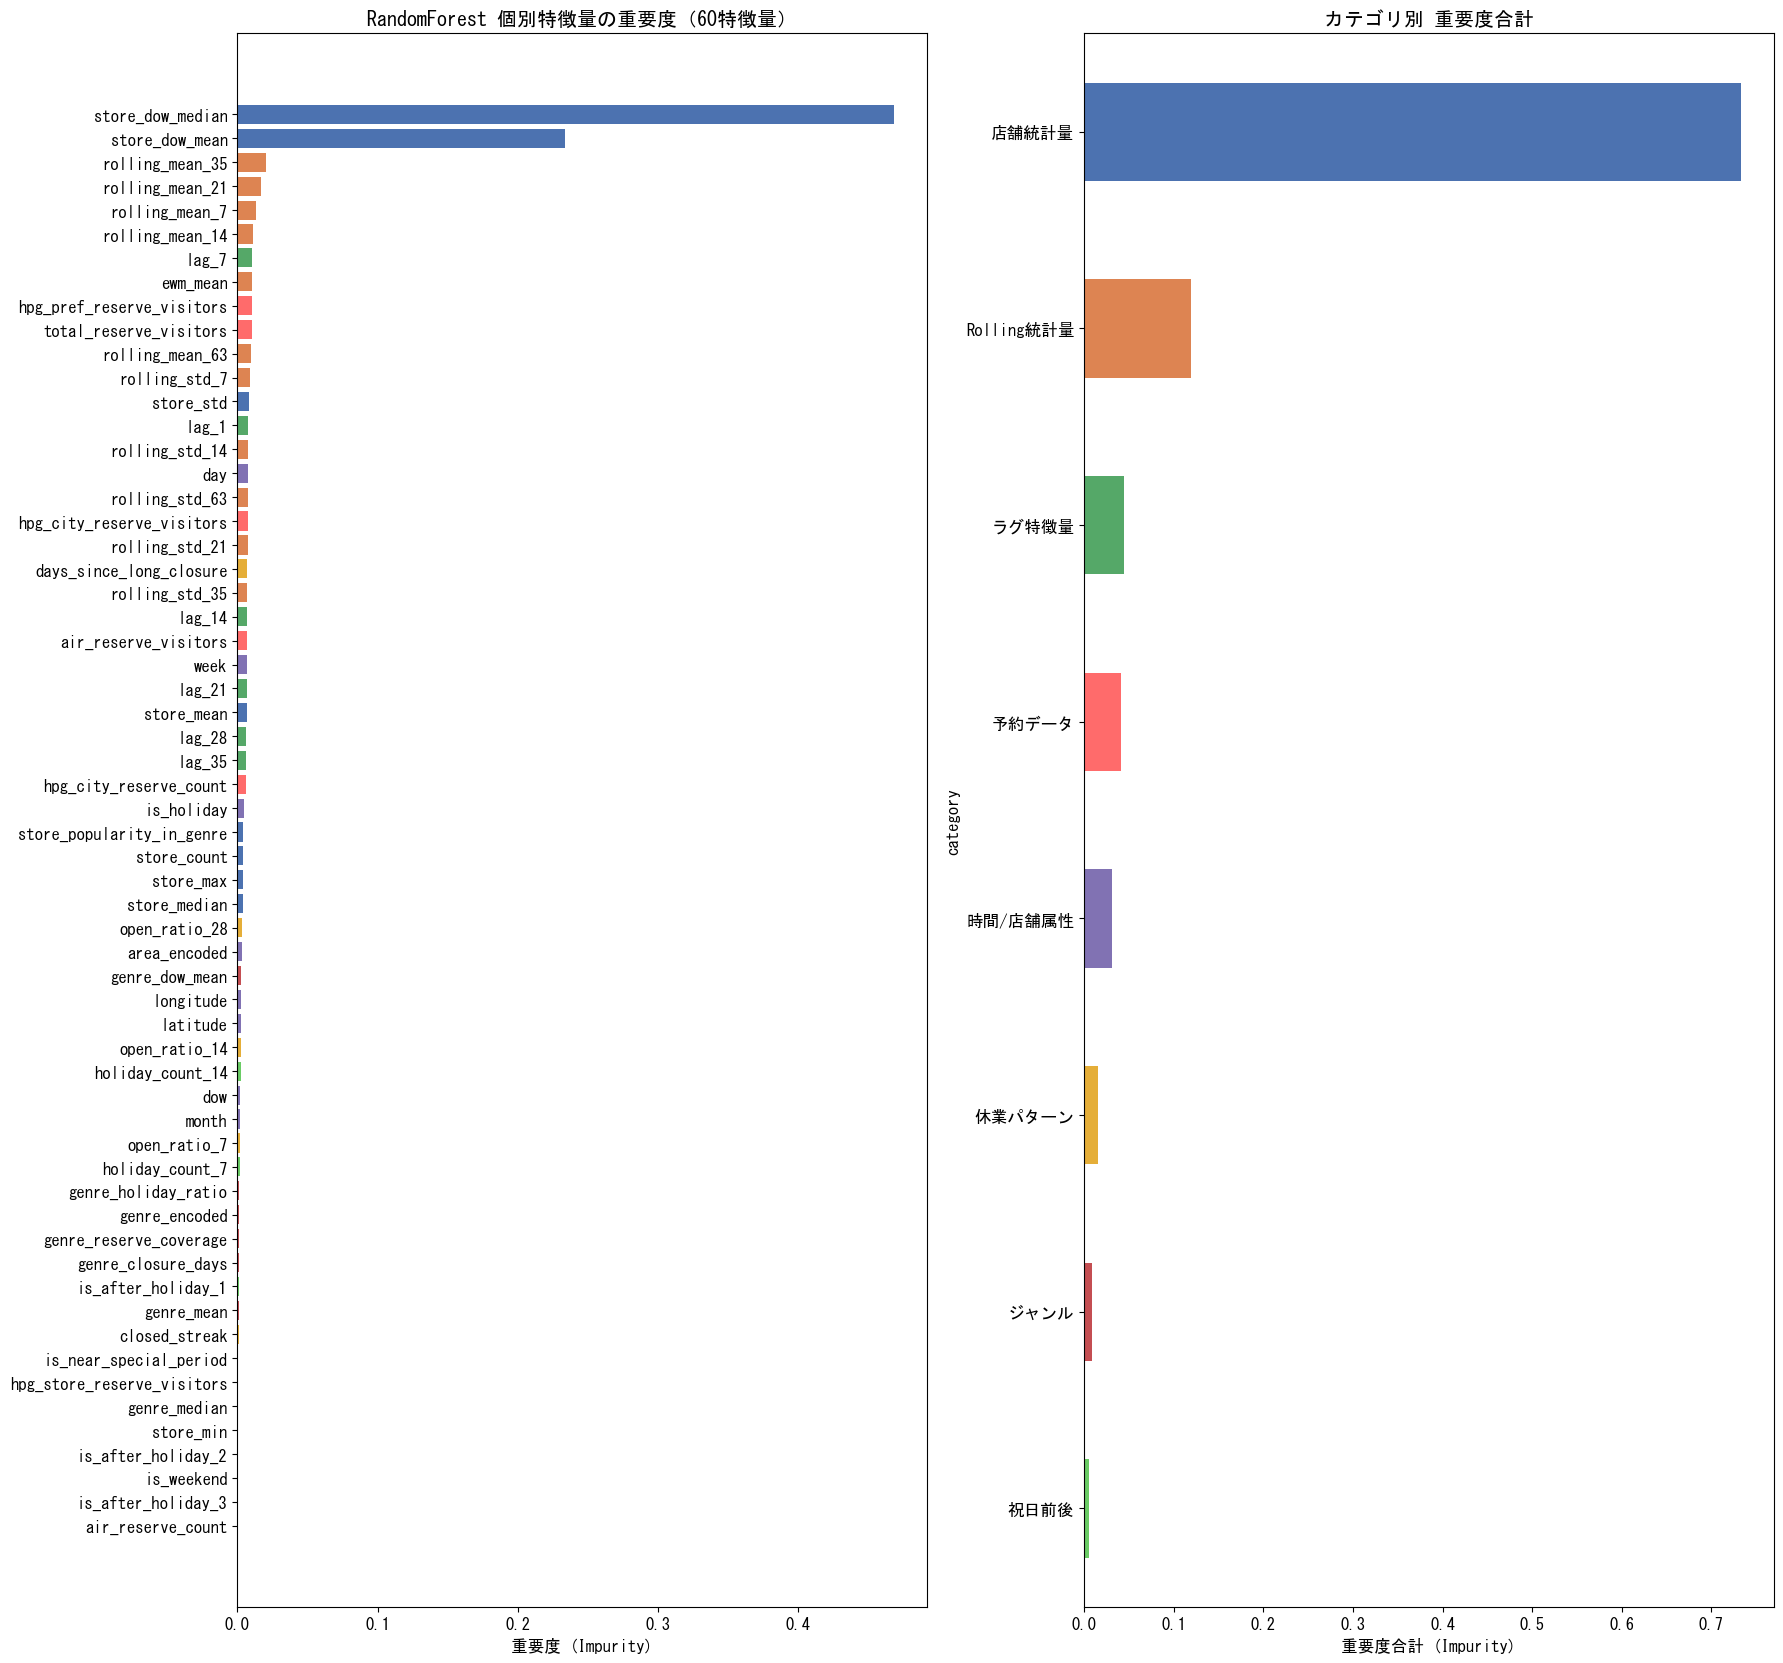


=== 上位10特徴量 ===
  [店舗統計量   ] store_dow_median: 0.4685 (46.8%)
  [店舗統計量   ] store_dow_mean: 0.2339 (23.4%)
  [Rolling統計量] rolling_mean_35: 0.0204 (2.0%)
  [Rolling統計量] rolling_mean_21: 0.0168 (1.7%)
  [Rolling統計量] rolling_mean_7: 0.0134 (1.3%)
  [Rolling統計量] rolling_mean_14: 0.0111 (1.1%)
  [ラグ特徴量   ] lag_7: 0.0105 (1.0%)
  [Rolling統計量] ewm_mean: 0.0103 (1.0%)
  [予約データ   ] hpg_pref_reserve_visitors: 0.0102 (1.0%) [予約]
  [予約データ   ] total_reserve_visitors: 0.0102 (1.0%) [予約]

  予約データ合計: 4.1%


In [8]:
importance = pd.DataFrame({
    'feature': all_features_v2,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    elif name.startswith(('hpg_', 'air_reserve', 'total_reserve')):
        return '予約データ'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

color_map = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65', '予約データ': '#FF6B6B'
}

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features_v2) * 0.28)))

colors = importance['category'].map(color_map)
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Impurity)')
axes[0].set_title('RandomForest 個別特徴量の重要度（60特徴量）')

cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_colors = [color_map.get(c, 'gray') for c in cat_imp.index]
cat_imp.plot(kind='barh', ax=axes[1], color=cat_colors)
axes[1].set_xlabel('重要度合計 (Impurity)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

total_imp = importance['importance'].sum()
reserve_share = importance[importance['category'] == '予約データ']['importance'].sum() / total_imp * 100

print(f'\n=== 上位10特徴量 ===')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    pct = row['importance'] / total_imp * 100
    marker = ' [予約]' if row['category'] == '予約データ' else ''
    print(f'  [{row["category"]:8s}] {row["feature"]}: {row["importance"]:.4f} ({pct:.1f}%){marker}')
print(f'\n  予約データ合計: {reserve_share:.1f}%')

---
## 7. 既存モデルとの比較

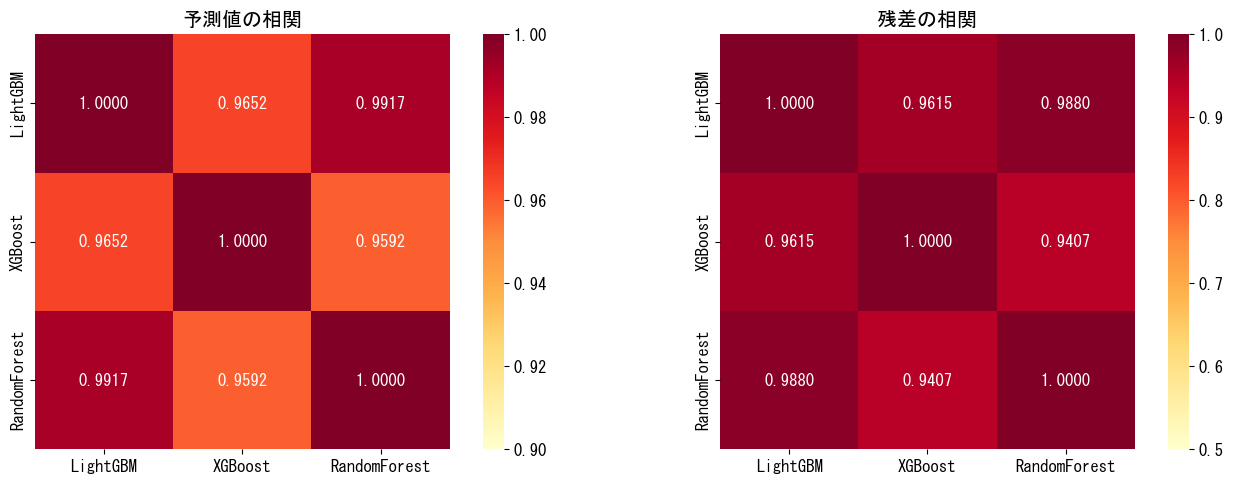


=== アンサンブル効果（単純平均） ===
  LightGBM単体:              0.50253
  XGBoost単体:               0.48972
  RandomForest単体:          0.51215
  LGB + XGB 平均:            0.48938
  LGB + XGB + RF 平均:       0.48993


In [9]:
# 3モデルの予測値の相関行列
pred_df = pd.DataFrame({
    'LightGBM': prev_lgbm['valid_pred'],
    'XGBoost': prev_xgb['valid_pred'],
    'RandomForest': pred,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 予測値の相関ヒートマップ
corr_matrix = pred_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], square=True, vmin=0.9, vmax=1.0)
axes[0].set_title('予測値の相関')

# 残差の相関ヒートマップ
resid_df = pd.DataFrame({
    'LightGBM': prev_lgbm['residuals'],
    'XGBoost': prev_xgb['residuals'],
    'RandomForest': residuals,
})
resid_corr = resid_df.corr()
sns.heatmap(resid_corr, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1], square=True, vmin=0.5, vmax=1.0)
axes[1].set_title('残差の相関')

plt.tight_layout()
plt.show()

# 単純平均アンサンブルの効果を確認
ensemble_2 = (prev_lgbm['valid_pred'] + prev_xgb['valid_pred']) / 2
ensemble_3 = (prev_lgbm['valid_pred'] + prev_xgb['valid_pred'] + pred) / 3
score_ens2 = rmsle(valid_df['visitors'], ensemble_2)
score_ens3 = rmsle(valid_df['visitors'], ensemble_3)

print(f'\n=== アンサンブル効果（単純平均） ===')
print(f'  LightGBM単体:              {prev_lgbm["score_single"]:.5f}')
print(f'  XGBoost単体:               {prev_xgb["score_single"]:.5f}')
print(f'  RandomForest単体:          {score_single:.5f}')
print(f'  LGB + XGB 平均:            {score_ens2:.5f}')
print(f'  LGB + XGB + RF 平均:       {score_ens3:.5f}')

---
## 8. ハイパーパラメータチューニング（Optuna）

In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30  # RFは学習が遅いためtrial数を抑える

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'max_samples': 0.8,
        'random_state': SEED,
        'n_jobs': -1,
    }

    fold_scores = []
    for fold in val_folds:
        val_start = pd.Timestamp(fold['val_start'])
        val_end = pd.Timestamp(fold['val_end'])

        train_mask = full_df['visit_date'] < val_start
        valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)

        fold_train = full_df[train_mask]
        fold_valid = full_df[valid_mask]

        if len(fold_train) == 0 or len(fold_valid) == 0:
            continue

        X_tr = fold_train[all_features_v2].fillna(-999)
        y_tr = np.log1p(fold_train['visitors'])
        X_va = fold_valid[all_features_v2].fillna(-999)
        y_va_raw = fold_valid['visitors']

        m = RandomForestRegressor(**params)
        m.fit(X_tr, y_tr)

        p = np.expm1(m.predict(X_va))
        s = rmsle(y_va_raw, p)
        fold_scores.append(s)

    return np.mean(fold_scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'=== Optuna チューニング結果（{N_TRIALS} trials, {len(val_folds)}-fold CV） ===')
print(f'  ベストCV RMSLE: {study.best_value:.5f}')
print(f'  チューニング前CV RMSLE: {np.mean(cv_scores):.5f}')
print(f'  改善幅: {np.mean(cv_scores) - study.best_value:.5f}')
print(f'\n  ベストパラメータ:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

# ベストパラメータでSingle Splitの再学習（予測値保存用）
best_rf_params = {
    **study.best_params,
    'max_samples': 0.8,
    'random_state': SEED,
    'n_jobs': -1,
}
X_train_opt = train_df[all_features_v2].fillna(-999)
y_train_opt = np.log1p(train_df['visitors'])
X_valid_opt = valid_df[all_features_v2].fillna(-999)
y_valid_opt = valid_df['visitors'].values

model_tuned = RandomForestRegressor(**best_rf_params)
model_tuned.fit(X_train_opt, y_train_opt)

pred_tuned_log = model_tuned.predict(X_valid_opt)
pred_tuned = np.expm1(pred_tuned_log)
score_tuned = rmsle(y_valid_opt, pred_tuned)
residuals_tuned = np.log1p(y_valid_opt) - pred_tuned_log

print(f'\n=== チューニング後モデル（Single Split） ===')
print(f'  RandomForest (チューニング前): {score_single:.5f}')
print(f'  RandomForest (チューニング後): {score_tuned:.5f}')
print(f'  LightGBM:                      {prev_lgbm["score_single"]:.5f}')
print(f'  XGBoost:                       {prev_xgb["score_single"]:.5f}')

# チューニング後のアンサンブルも確認
ensemble_3_tuned = (prev_lgbm['valid_pred'] + prev_xgb['valid_pred'] + pred_tuned) / 3
score_ens3_tuned = rmsle(y_valid_opt, ensemble_3_tuned)
print(f'\n  LGB+XGB+RF(tuned) 平均: {score_ens3_tuned:.5f} (チューニング前: {score_ens3:.5f})')

  0%|          | 0/30 [00:00<?, ?it/s]

=== Optuna チューニング結果（30 trials, 5-fold CV） ===
  ベストCV RMSLE: 0.50892
  チューニング前CV RMSLE: 0.51057
  改善幅: 0.00166

  ベストパラメータ:
    n_estimators: 700
    max_depth: 24
    min_samples_split: 21
    min_samples_leaf: 3
    max_features: 0.5376388141678947

=== チューニング後モデル（Single Split） ===
  RandomForest (チューニング前): 0.51215
  RandomForest (チューニング後): 0.50698
  LightGBM:                      0.50253
  XGBoost:                       0.48972

  LGB+XGB+RF(tuned) 平均: 0.48971 (チューニング前: 0.48993)


---
## 9. まとめと次ステップ

In [11]:
print('=== モデル比較 ===')
print(f'{"モデル":<20s} {"Single RMSLE":>14s} {"CV平均 RMSLE":>14s}')
print('-' * 52)
print(f'{"ベースライン(店舗×DOW)":<20s} {baseline_rmsle:>14.5f} {"---":>14s}')
print(f'{"LightGBM":<20s} {prev_lgbm["score_single"]:>14.5f} {prev_lgbm["cv_mean"]:>14.5f}')
print(f'{"XGBoost":<20s} {prev_xgb["score_single"]:>14.5f} {prev_xgb["cv_mean"]:>14.5f}')
print(f'{"RandomForest":<20s} {score_single:>14.5f} {np.mean(cv_scores):>14.5f}')
print(f'{"RF(tuned)":<20s} {score_tuned:>14.5f} {study.best_value:>14.5f}')
print(f'\n=== ベースラインとの比較 ===')
print(f'  ベースライン → RF改善: {baseline_rmsle - score_single:.5f} ({(baseline_rmsle - score_single)/baseline_rmsle*100:.1f}%)')
print(f'  ベースライン → RF(tuned)改善: {baseline_rmsle - score_tuned:.5f} ({(baseline_rmsle - score_tuned)/baseline_rmsle*100:.1f}%)')
print(f'\n=== アンサンブル ===')
print(f'  LGB+XGB平均:          {score_ens2:.5f}')
print(f'  LGB+XGB+RF平均:       {score_ens3:.5f}')
print(f'  LGB+XGB+RF(tuned)平均: {score_ens3_tuned:.5f}')
print(f'\n→ 次のステップ（03-4）でCatBoostモデルを構築する。')

=== モデル比較 ===
モデル                    Single RMSLE     CV平均 RMSLE
----------------------------------------------------
ベースライン(店舗×DOW)              0.54977            ---
LightGBM                    0.50253        0.50088
XGBoost                     0.48972        0.50196
RandomForest                0.51215        0.51057
RF(tuned)                   0.50698        0.50892

=== ベースラインとの比較 ===
  ベースライン → RF改善: 0.03762 (6.8%)
  ベースライン → RF(tuned)改善: 0.04279 (7.8%)

=== アンサンブル ===
  LGB+XGB平均:          0.48938
  LGB+XGB+RF平均:       0.48993
  LGB+XGB+RF(tuned)平均: 0.48971

→ 次のステップ（03-4）でCatBoostモデルを構築する。


In [12]:
# 中間データの保存
results_03_3 = {
    'valid_pred': pred,
    'valid_pred_log': pred_log,
    'valid_actual': valid_df['visitors'].values,
    'score_single': score_single,
    'cv_scores': cv_scores,
    'cv_mean': np.mean(cv_scores),
    'cv_std': np.std(cv_scores),
    'feature_importance': importance,
    'params': rf_params,
    'residuals': residuals,
    'ensemble_scores': {
        'lgb_xgb': score_ens2,
        'lgb_xgb_rf': score_ens3,
    },
    # ベースライン結果
    'baseline_rmsle': baseline_rmsle,
    'baseline_pred': baseline_pred,
    'store_dow_median': store_dow_median,
    # チューニング後の結果
    'tuned_params': best_rf_params,
    'tuned_score': score_tuned,
    'tuned_valid_pred': pred_tuned,
    'tuned_valid_pred_log': pred_tuned_log,
    'tuned_residuals': residuals_tuned,
    'tuned_ensemble_scores': {
        'lgb_xgb_rf_tuned': score_ens3_tuned,
    },
    'optuna_best_value': study.best_value,
}

with open(INTERMEDIATE_DIR / '03-3_rf_results.pkl', 'wb') as f:
    pickle.dump(results_03_3, f)

# チューニング前モデル
joblib.dump(model, INTERMEDIATE_DIR / '03-3_rf_model.joblib')
# チューニング後モデル
joblib.dump(model_tuned, INTERMEDIATE_DIR / '03-3_rf_model_tuned.joblib')

print('中間データ保存完了:')
print(f'  結果: {INTERMEDIATE_DIR / "03-3_rf_results.pkl"}')
print(f'  モデル（チューニング前）: {INTERMEDIATE_DIR / "03-3_rf_model.joblib"}')
print(f'  モデル（チューニング後）: {INTERMEDIATE_DIR / "03-3_rf_model_tuned.joblib"}')

中間データ保存完了:
  結果: intermediate\03-3_rf_results.pkl
  モデル（チューニング前）: intermediate\03-3_rf_model.joblib
  モデル（チューニング後）: intermediate\03-3_rf_model_tuned.joblib
